# CIFAR-10 / ResNet18 — headline + parameter-fraction

Sven vs baselines on ResNet18 (Gram makes this tractable). Headline convergence, and the Fig-5 parameter-fraction sweep (accuracy vs fraction of parameters updated).

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import add_derived, best_per_method, valid, loss_curve, steps_to_target, method_order
from pathlib import Path
set_style()
PLOT_DIR = Path('plots/cifar'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
def sven_color(m): return 'k' if m=='Sven' else None
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
head={'label-reg':'cifar10_resnet_scan_labelRegression','CE':'cifar10_resnet_ce_scan'}
pf={'label-reg (paper)':'cifar10_resnet_paramFrac_scan_labelReg',
    'label-reg (rebuttal 3-seed)':'rebuttal_fig5_cifar_paramfrac_scan'}
H={}; PF={}
for t,n in head.items():
    try: H[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)
for t,n in pf.items():
    try: PF[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)

Loaded 78 runs from ../experiment_results/cifar10_resnet_scan_labelRegression/ (directory format, slim)
Loaded 79 runs from ../experiment_results/cifar10_resnet_ce_scan/ (directory format, slim)
Loaded 5 runs from ../experiment_results/cifar10_resnet_paramFrac_scan_labelReg/ (directory format, slim)
Loaded 15 runs from ../experiment_results/rebuttal_fig5_cifar_paramfrac_scan/ (directory format, slim)


### Headline: best per method

In [3]:
for t,df in H.items():
    b=best_per_method(df, by='final_val_loss').sort_values('final_val_loss')
    print(f'== CIFAR {t} ==')
    for _,r in b.iterrows():
        acc=f' acc={r.final_val_acc:.3f}' if r.final_val_acc==r.final_val_acc else ''
        print(f'  {r.method:10s} val={r.final_val_loss:.4f}{acc}')

== CIFAR label-reg ==
  Adam       val=0.3928 acc=0.740
  LBFGS      val=0.4181 acc=0.716
  RMSprop    val=0.4267 acc=0.741
  PolyakSGD  val=0.4426 acc=0.718
  SGD        val=0.7315 acc=0.445
  Sven       val=1.2210 acc=0.244
== CIFAR CE ==
  LBFGS      val=0.8748 acc=0.731
  Adam       val=1.1864 acc=0.707
  RMSprop    val=1.2480 acc=0.761
  Sven       val=1.3002 acc=0.538
  SGD        val=1.3255 acc=0.549
  PolyakSGD  val=1.7175 acc=0.647


### Fig-5: accuracy vs parameter fraction (Sven)

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

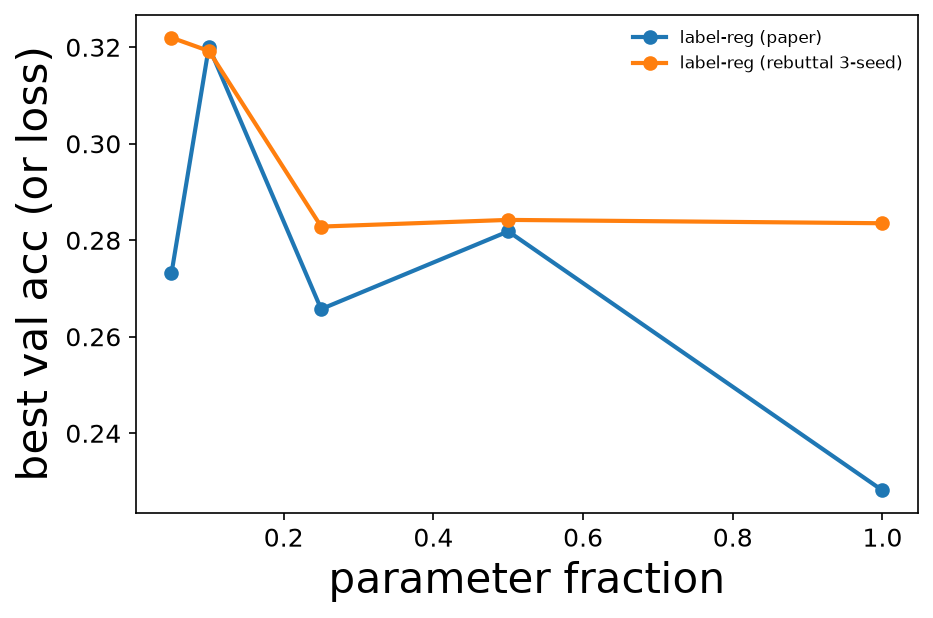

In [4]:
fig,ax=plt.subplots(figsize=(6.5,4.4))
for t,df in PF.items():
    d=valid(df)
    if 'param_fraction' not in d or d.empty: continue
    g=d.loc[d.groupby('param_fraction')['final_val_loss'].idxmin()].sort_values('param_fraction')
    y = g['final_val_acc'] if g['final_val_acc'].notna().any() else g['final_val_loss']
    ax.plot(g['param_fraction'], y, marker='o', label=t)
ax.set_xlabel('parameter fraction'); ax.set_ylabel('best val acc (or loss)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'paramfrac.pdf',bbox_inches='tight'); plt.show()